In [69]:
from subprocess import check_output
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [61]:
def separation(D, labels):
    dim = len(D)
    A, B = 0, 0
    ca, cb = 0, 0
    for i in range(dim):
        for j in range(dim):
            k, l = labels[i], labels[j]
            if k == l:
                A += D[i][j]
                ca += 1
            else:
                B += D[i][j]
                cb += 1
    r = (A / ca) / (B / cb)
    return r

In [12]:
lsmash = '/home/yhuang10/D3M/zutil_/lsmash'
dtw = '/home/yhuang10/D3M/zutil_/dtw'

## lsmash with fixed base set

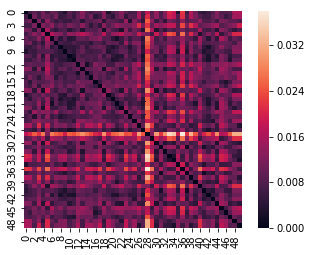

In [48]:
cmd_lsmash = '{} -f seq.dat -T symbolic -o lsmash.dst -S 0'.format(lsmash)
status_lsmash = check_output(cmd_lsmash, shell=True)
lsmash_matrix = np.genfromtxt('lsmash.dst')
sns.heatmap(lsmash_matrix)
plt.gca().set_aspect(1)
plt.show()

## dtw

In [ ]:
for window_size in window_sizes:
    dst_fname = 'dtw_{}.dst'.format(window_size)
    cmd_dtw = '{} seq.dat {} {}'.format(dtw, window_size, dst_fname)
    status_dtw = check_output(cmd_dtw, shell=True)

## lsmash with inferred base set

In [ ]:
! /home/yhuang10/TimeSeriesAnalysis/PFSA/GenESeSS_/bin/genESeSS -f seq_1.dat -T symbolic -D row -o inferred_1.cfg -v 0

In [32]:
! /home/yhuang10/TimeSeriesAnalysis/PFSA/GenESeSS_/bin/genESeSS -f seq_2.dat -T symbolic -D row -o inferred_2.cfg -v 0

multi-stream genESeSS..
 2.515115s wall, 2.470000s user + 0.050000s system = 2.520000s CPU (100.2%)



In [37]:
! /home/yhuang10/D3M/zutil_/lsmash -f seq.dat -D row -T symbolic -F inferred_1.cfg inferred_2.cfg -S 0 -o lsmash_inferred.dst

 0.030361s wall, 0.390000s user + 0.010000s system = 0.400000s CPU (1317.5%)


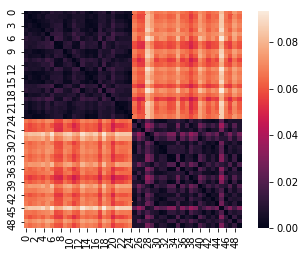

In [77]:
lsmash_matrix_inferred = np.genfromtxt('lsmash_inferred.dst')
plt.figure()
sns.heatmap(lsmash_matrix_inferred)
plt.gca().set_aspect(1)
plt.show()

## Plot

In [87]:
window_sizes = [0, 2, 5, 10, 50]
data, titles = [], []
for window_size in window_sizes:
    dst_fname = 'dtw_{}.dst'.format(window_size)
    dtw_matrix = np.genfromtxt(dst_fname)
    # dtw_matrix = StandardScaler().fit_transform(dtw_matrix)
    matrix = dtw_matrix / dtw_matrix.max()
    data.append(matrix)
    titles.append('DTW{}'.format(window_size))
    
matrix = lsmash_matrix_inferred / lsmash_matrix_inferred.max()
data.append(matrix)
titles.append('Smash2.0 with\ninferred base set')

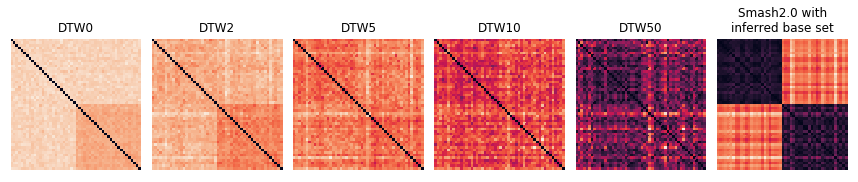

In [92]:
height = 2.5
width = (len(data)) * height
fig, axes = plt.subplots(
    1, len(data), 
    figsize=(width, height), 
    gridspec_kw={'wspace': 0.08})

for matrix, ax, title in zip(data, axes, titles):
    sns.heatmap(matrix, cbar=False, ax=ax, xticklabels=False, yticklabels=False)

    # fix the cut-off problem
    b, t = ax.get_ylim()
    ax.set_ylim(b + .5, t - .5)
    
    ax.set_aspect(1)
    ax.tick_params(left=False, bottom=False)
    ax.set_title(title, fontsize=12)

plt.savefig('fool_dtw.pdf', dpi=400,bbox_inches='tight')
plt.show()